## Setup TMDb API Key

To use The Movie Database (TMDb) API, you'll need an API key. If you don't have one, you can get one from their website: [https://www.themoviedb.org/documentation/api](https://www.themoviedb.org/documentation/api)

Once you have your API key, store it securely in Colab's Secrets Manager (accessible via the "🔑" icon in the left panel) with the name `TMDB_API_KEY`.

In [1]:
import requests
import pandas as pd
# from google.colab import userdata # Commented out as key is provided directly

# Get the API key from Colab Secrets (or use the one provided by the user)
TMDB_API_KEY = 'c8429c02b6619999751d5aa984d0b44f' # User provided API Key
# TMDB_API_KEY = userdata.get('TMDB_API_KEY')

if not TMDB_API_KEY:
    raise ValueError("TMDb API Key not found. Please set 'TMDB_API_KEY' in Colab Secrets or provide it directly.")

print("TMDb API key loaded successfully.")

TMDb API key loaded successfully.


## Fetching Popular Movies

Let's start by fetching a list of popular movies from TMDb to use as our initial dataset. We'll extract relevant information like movie ID, title, overview, and release date.

In [3]:
import requests
import pandas as pd
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type

def fetch_popular_movies(api_key, num_pages=5):
    movies_data = []
    base_url = "https://api.themoviedb.org/3/movie/popular"

    @retry(wait=wait_exponential(multiplier=1, min=4, max=10),
           stop=stop_after_attempt(5),
           retry=retry_if_exception_type(requests.exceptions.HTTPError))
    def fetch_page_with_retry(page_num):
        params = {
            "api_key": api_key,
            "language": "en-US",
            "page": page_num
        }
        response = requests.get(base_url, params=params)
        response.raise_for_status() # Raise an exception for HTTP errors
        return response.json()

    for page in range(1, num_pages + 1):
        try:
            data = fetch_page_with_retry(page)
            movies_data.extend(data['results'])
        except requests.exceptions.HTTPError as e:
            print(f"Failed to fetch page {page} after retries: {e}")
            # Optionally, you can decide to break or continue here
            # For now, we'll continue to try other pages if one fails
            continue
        except Exception as e:
            print(f"An unexpected error occurred while fetching page {page}: {e}")
            continue

    # Convert to DataFrame
    df_movies = pd.DataFrame(movies_data)

    # Select and rename relevant columns
    df_movies = df_movies[['id', 'title', 'overview', 'release_date', 'vote_average', 'vote_count', 'genre_ids', 'popularity']]
    df_movies = df_movies.rename(columns={'id': 'movie_id'})

    return df_movies

# Fetch popular movies
popular_movies_df = fetch_popular_movies(TMDB_API_KEY)
display(popular_movies_df.head())

,movie_id,title,overview,release_date,vote_average,vote_count,genre_ids,popularity
0,1226863,The Super Mario Galaxy Movie,Having thwarted Bowser's previous plot to marr...,2026-04-01,6.700,749,"[10751, 35, 12, 14, 16]",471.5305
1,1318447,Apex,A grieving woman pushing her limits on a solo ...,2026-04-24,6.415,712,"[28, 53]",395.3686
2,1007757,Swapped,"A small woodland creature and a majestic bird,...",2026-05-01,7.972,89,"[12, 16, 18, 10751, 14]",380.4680
3,10867,Malena,12-year-old Renato experiences three significa...,2000-10-27,7.400,2495,[18],318.4266
4,1198994,Send Help,Two colleagues become stranded on a deserted i...,2026-01-22,6.988,1196,"[27, 53, 35]",247.3239


Now that we have a list of popular movies, the next step would typically involve:
1.  **Fetching movie details and genres**: The `genre_ids` need to be mapped to actual genre names.
2.  **Fetching reviews**: To build a review-based recommendation system, we'll need to get actual user reviews for these movies.
3.  **Data Preprocessing**: Clean and prepare the text data from overviews and reviews for analysis (e.g., tokenization, stop word removal).

## Fetching Movie Genres

To make our movie data more understandable and usable for recommendations, let's fetch the list of movie genres from TMDb and map the `genre_ids` in our `popular_movies_df` to their corresponding names.

In [4]:
import json

def fetch_movie_genres(api_key):
    base_url = "https://api.themoviedb.org/3/genre/movie/list"
    params = {
        "api_key": api_key,
        "language": "en-US"
    }

    # Using the retry mechanism for genre fetching as well
    @retry(wait=wait_exponential(multiplier=1, min=4, max=10),
           stop=stop_after_attempt(5),
           retry=retry_if_exception_type(requests.exceptions.HTTPError))
    def fetch_genres_with_retry():
        response = requests.get(base_url, params=params)
        response.raise_for_status()
        return response.json()

    try:
        data = fetch_genres_with_retry()
        genres = {genre['id']: genre['name'] for genre in data['genres']}
        return genres
    except requests.exceptions.HTTPError as e:
        print(f"Failed to fetch movie genres after retries: {e}")
        return {}
    except Exception as e:
        print(f"An unexpected error occurred while fetching genres: {e}")
        return {}

# Fetch genres
genre_mapping = fetch_movie_genres(TMDB_API_KEY)
print("Fetched movie genres:")
print(json.dumps(genre_mapping, indent=2))

# Map genre_ids to genre names in popular_movies_df
def map_genre_ids_to_names(genre_ids, genre_map):
    if isinstance(genre_ids, list):
        return [genre_map.get(gid, 'Unknown') for gid in genre_ids]
    return []

popular_movies_df['genres'] = popular_movies_df['genre_ids'].apply(lambda x: map_genre_ids_to_names(x, genre_mapping))

display(popular_movies_df[['title', 'genres', 'genre_ids']].head())


Fetched movie genres:
{
  "28": "Action",
  "12": "Adventure",
  "16": "Animation",
  "35": "Comedy",
  "80": "Crime",
  "99": "Documentary",
  "18": "Drama",
  "10751": "Family",
  "14": "Fantasy",
  "36": "History",
  "27": "Horror",
  "10402": "Music",
  "9648": "Mystery",
  "10749": "Romance",
  "878": "Science Fiction",
  "10770": "TV Movie",
  "53": "Thriller",
  "10752": "War",
  "37": "Western"
}


,title,genres,genre_ids
0,The Super Mario Galaxy Movie,"[Family, Comedy, Adventure, Fantasy, Animation]","[10751, 35, 12, 14, 16]"
1,Apex,"[Action, Thriller]","[28, 53]"
2,Swapped,"[Adventure, Animation, Drama, Family, Fantasy]","[12, 16, 18, 10751, 14]"
3,Malena,[Drama],[18]
4,Send Help,"[Horror, Thriller, Comedy]","[27, 53, 35]"


With movie genres mapped, the next logical step is to fetch user reviews for these movies. This is a crucial component for a review-based recommendation system.

## Fetching Movie Reviews

To build a personalized recommendation system based on reviews, we need to fetch actual user reviews for the movies we have. We'll iterate through our `popular_movies_df` and make API calls to retrieve reviews for each movie.

In [5]:
import time

def fetch_movie_reviews(api_key, movie_id, num_pages=1):
    reviews_data = []
    base_url = f"https://api.themoviedb.org/3/movie/{movie_id}/reviews"

    @retry(wait=wait_exponential(multiplier=1, min=4, max=10),
           stop=stop_after_attempt(5),
           retry=retry_if_exception_type(requests.exceptions.HTTPError))
    def fetch_review_page_with_retry(page_num):
        params = {
            "api_key": api_key,
            "language": "en-US",
            "page": page_num
        }
        response = requests.get(base_url, params=params)
        response.raise_for_status()
        return response.json()

    for page in range(1, num_pages + 1):
        try:
            data = fetch_review_page_with_retry(page)
            if data['results']:
                reviews_data.extend(data['results'])
            else:
                break # No more reviews on this page
            if page < data.get('total_pages', page):
                time.sleep(0.1) # Be polite to the API
            else:
                break
        except requests.exceptions.HTTPError as e:
            print(f"Failed to fetch reviews for movie ID {movie_id}, page {page} after retries: {e}")
            break
        except Exception as e:
            print(f"An unexpected error occurred while fetching reviews for movie ID {movie_id}, page {page}: {e}")
            break

    return reviews_data

all_reviews = []
# It's good practice to limit the number of movies to fetch reviews for initially
# to avoid hitting API rate limits or taking too long.
# Let's fetch reviews for the first 20 popular movies.

print(f"Fetching reviews for {len(popular_movies_df)} movies. This may take a while...")

for index, row in popular_movies_df.iterrows():
    movie_id = row['movie_id']
    movie_title = row['title']
    reviews = fetch_movie_reviews(TMDB_API_KEY, movie_id, num_pages=1) # Fetch reviews from the first page only for now

    for review in reviews:
        review['movie_id'] = movie_id
        review['movie_title'] = movie_title
        all_reviews.append(review)

    # Add a small delay between movie requests to avoid hitting rate limits
    time.sleep(0.05)

df_reviews = pd.DataFrame(all_reviews)

print(f"Successfully fetched {len(df_reviews)} reviews.")
display(df_reviews.head())


Fetching reviews for 100 movies. This may take a while...
An unexpected error occurred while fetching reviews for movie ID 1010755, page 1: RetryError[<Future at 0x7c33aad9f860 state=finished raised HTTPError>]
Successfully fetched 354 reviews.


,author,author_details,content,created_at,id,updated_at,url,movie_id,movie_title
0,Manuel São Bento,"{'name': 'Manuel São Bento', 'username': 'msbr...",Full review: https://fandomwire.com/the-super-...,2026-03-31T19:05:34Z,69cc1afe574f58b99cc35932,2026-03-31T19:05:34Z,https://www.themoviedb.org/review/69cc1afe574f...,1226863,The Super Mario Galaxy Movie
1,Suhaixy,"{'name': '', 'username': 'Suhaixy', 'avatar_pa...",**A film that could have had great potential**...,2026-04-01T20:27:19Z,69cd7fa7b40785ab8ba636ee,2026-04-01T21:11:19Z,https://www.themoviedb.org/review/69cd7fa7b407...,1226863,The Super Mario Galaxy Movie
2,Chandler Danier,"{'name': 'Chandler Danier', 'username': 'chand...",This movie is stupid trash. You should know th...,2026-04-03T15:43:44Z,69cfe03046af586a52d2913b,2026-04-03T15:43:44Z,https://www.themoviedb.org/review/69cfe03046af...,1226863,The Super Mario Galaxy Movie
3,Aadesh,"{'name': 'Aadesh', 'username': 'Aadeshgamerfun...",YOU KNOW WHAT?\r\nThis movie is good because I...,2026-04-04T02:00:20Z,69d070b40ec5f2df8f2f7c5b,2026-04-05T17:32:16Z,https://www.themoviedb.org/review/69d070b40ec5...,1226863,The Super Mario Galaxy Movie
4,certifiedcritic,"{'name': '', 'username': 'certifiedcritic', 'a...",It was engaging from start to finish.\r\n\r\nM...,2026-04-07T02:27:43Z,69d46b9f7de67d18b4edf321,2026-04-08T00:28:03Z,https://www.themoviedb.org/review/69d46b9f7de6...,1226863,The Super Mario Galaxy Movie


Now that we have collected movie reviews, the next critical step is **Data Preprocessing**. This involves:

1.  **Text Cleaning**: Removing special characters, HTML tags, numbers, and converting text to lowercase.
2.  **Tokenization**: Breaking down review text into individual words or tokens.
3.  **Stop Word Removal**: Eliminating common words (like 'the', 'is', 'a') that don't carry significant meaning.
4.  **Lemmatization/Stemming**: Reducing words to their base form.
5.  **Feature Extraction**: Converting the cleaned text into numerical representations that machine learning models can understand (e.g., TF-IDF, Word Embeddings).

These steps will prepare the data for building our recommendation model.

## Data Preprocessing: Cleaning and Tokenizing Reviews

Before we can use the reviews to build a recommendation system, we need to preprocess the text data. This involves several steps:

1.  **Text Cleaning**: Removing special characters, HTML tags, numbers, and converting text to lowercase.
2.  **Tokenization**: Breaking down review text into individual words or tokens.
3.  **Stop Word Removal**: Eliminating common words (like 'the', 'is', 'a') that don't carry significant meaning.
4.  **Lemmatization**: Reducing words to their base form to handle variations (e.g., 'running' -> 'run').

In [7]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str): # Ensure text is a string
        return ""
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 4. Remove special characters and numbers, keep only alphabetic characters
    text = re.sub(r'[^a-z]', ' ', text)
    # 5. Tokenization
    tokens = text.split()
    # 6. Stop word removal and Lemmatization
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 1]
    return ' '.join(processed_tokens)

# Apply preprocessing to the 'content' column of df_reviews
df_reviews['processed_content'] = df_reviews['content'].apply(preprocess_text)

print("Original review content for the first review:")
print(df_reviews['content'].iloc[0])
print("\nProcessed review content for the first review:")
print(df_reviews['processed_content'].iloc[0])

display(df_reviews[['movie_title', 'content', 'processed_content']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Original review content for the first review:
Full review: https://fandomwire.com/the-super-mario-galaxy-movie-review/

Rating: B+

"The Super Mario Galaxy Movie is a sequel that, while losing some of the narrative cohesion of its predecessor, gains massively in spectacle, ambition, and heart. Through animation that redefines the studio's standards and a Brian Tyler score that masterfully honors Nintendo's legacy, the film offers a memorable experience anchored by inspired vocal performances. For those who grew up with these characters, it's impossible to remain indifferent to the magic emanating from every animated frame or the way this space odyssey manages to transform nostalgia into something vibrant and new. It's a visually emotional feast that reaffirms the power of pure entertainment as a tool capable of transporting us back to the happiest moments of our personal history, proving that cinema is still the place where we can all become children again."

Processed review content f

,movie_title,content,processed_content
0,The Super Mario Galaxy Movie,Full review: https://fandomwire.com/the-super-...,full review rating super mario galaxy movie se...
1,The Super Mario Galaxy Movie,**A film that could have had great potential**...,film could great potential huge nintendo fan s...
2,The Super Mario Galaxy Movie,This movie is stupid trash. You should know th...,movie stupid trash know going know without tel...
3,The Super Mario Galaxy Movie,YOU KNOW WHAT?\r\nThis movie is good because I...,know movie good watched liked gaming lot rate ...
4,The Super Mario Galaxy Movie,It was engaging from start to finish.\r\n\r\nM...,engaging start finish minor gripe introduced s...


Now that the review text is preprocessed, the next step is **Feature Extraction**. This involves converting the textual data into numerical features that can be used by machine learning models. Common techniques include:

1.  **TF-IDF (Term Frequency-Inverse Document Frequency)**: A statistical measure that evaluates how relevant a word is to a document in a collection of documents.
2.  **Word Embeddings (e.g., Word2Vec, GloVe)**: Represent words as dense vectors in a continuous vector space, capturing semantic relationships.

For a first pass, we can start with TF-IDF to create a vector representation of each review.

## Feature Extraction: TF-IDF Vectorization

To build a recommendation system from text data, we need to convert the `processed_content` of our reviews into numerical features. TF-IDF is a common technique that reflects how important a word is to a document in a collection or corpus.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
# min_df ignores terms that have a document frequency strictly lower than the given threshold.
# max_df ignores terms that have a document frequency strictly higher than the given threshold.
# We'll use a relatively low min_df to keep more words, but avoid very rare ones.
# max_features limits the number of features (words) to the most frequent ones.
tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.8, max_features=5000)

# Fit and transform the processed review content
# Handle potential empty strings or NaNs in 'processed_content'
corpus = df_reviews['processed_content'].fillna('').tolist()
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# Display a sample of the TF-IDF matrix (e.g., first 5 rows and some feature names)
feature_names = tfidf_vectorizer.get_feature_names_out()
sample_tfidf_df = pd.DataFrame(tfidf_matrix[:5, :].toarray(), columns=feature_names)
display(sample_tfidf_df.head())

# Store the TF-IDF matrix for later use
df_reviews_tfidf = tfidf_matrix


TF-IDF matrix shape: (354, 1332)


,ability,able,absolute,absolutely,across,act,acting,action,actor,actual,...,yeah,year,yes,yet,york,young,zendaya,zero,zimmer,zombie
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.143105,0.0,0.0,...,0.0,0.0,0.0,0.161021,0.0,0.0,0.0,0.0,0.0,0.0


With the reviews now converted into a numerical TF-IDF matrix, we have the features ready for building a recommendation model. The next steps will likely involve:

1.  **Similarity Calculation**: Calculating the similarity between reviews or movies based on their TF-IDF vectors (e.g., cosine similarity).
2.  **Recommendation Logic**: Developing a method to recommend movies based on this similarity, perhaps by finding movies with similar review content.
3.  **User Profile Creation (Optional but Recommended)**: If we had actual user-specific reviews or ratings, we could create user profiles to provide more personalized recommendations.

## Sentiment Analysis of Reviews

To understand the nature of the reviews and create sentiment-based visualizations, we will perform sentiment analysis. We'll use NLTK's VADER (Valence Aware Dictionary and sEntiment Reasoner), a lexicon and rule-based sentiment analysis tool that is specifically attuned to sentiments expressed in social media, and works well for general text.

In [12]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon (if not already downloaded)
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return 'neutral' # Handle empty or non-string inputs
    score = sia.polarity_scores(text)
    # Classify based on compound score
    if score['compound'] >= 0.05:
        return 'positive'
    elif score['compound'] <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply sentiment analysis to the processed review content
df_reviews['sentiment'] = df_reviews['processed_content'].apply(get_sentiment)

print("Sentiment analysis complete. Here's a sample of reviews with their sentiment:")
display(df_reviews[['movie_title', 'processed_content', 'sentiment']].head())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Sentiment analysis complete. Here's a sample of reviews with their sentiment:


,movie_title,processed_content,sentiment
0,The Super Mario Galaxy Movie,full review rating super mario galaxy movie se...,positive
1,The Super Mario Galaxy Movie,film could great potential huge nintendo fan s...,positive
2,The Super Mario Galaxy Movie,movie stupid trash know going know without tel...,positive
3,The Super Mario Galaxy Movie,know movie good watched liked gaming lot rate ...,positive
4,The Super Mario Galaxy Movie,engaging start finish minor gripe introduced s...,positive


### Visualizing Review Sentiments

Now that we have assigned sentiment labels to each review, let's visualize the distribution of these sentiments and also explore how sentiments are distributed across different movies or genres.

/tmp/ipykernel_3583/3793119977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df_reviews, palette='viridis', order=['positive', 'neutral', 'negative'])


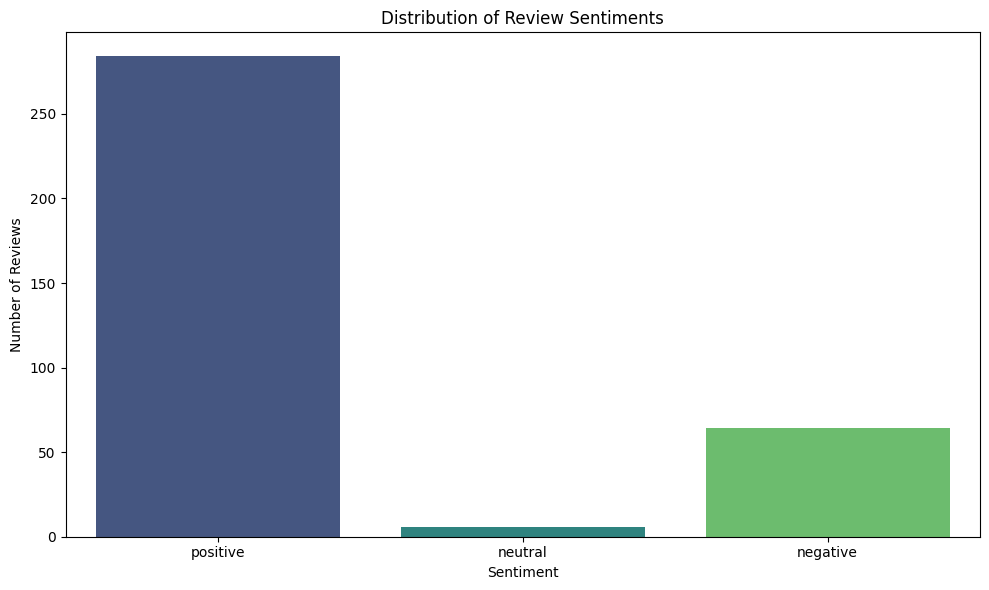

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment', data=df_reviews, palette='viridis', order=['positive', 'neutral', 'negative'])
plt.title('Distribution of Review Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()


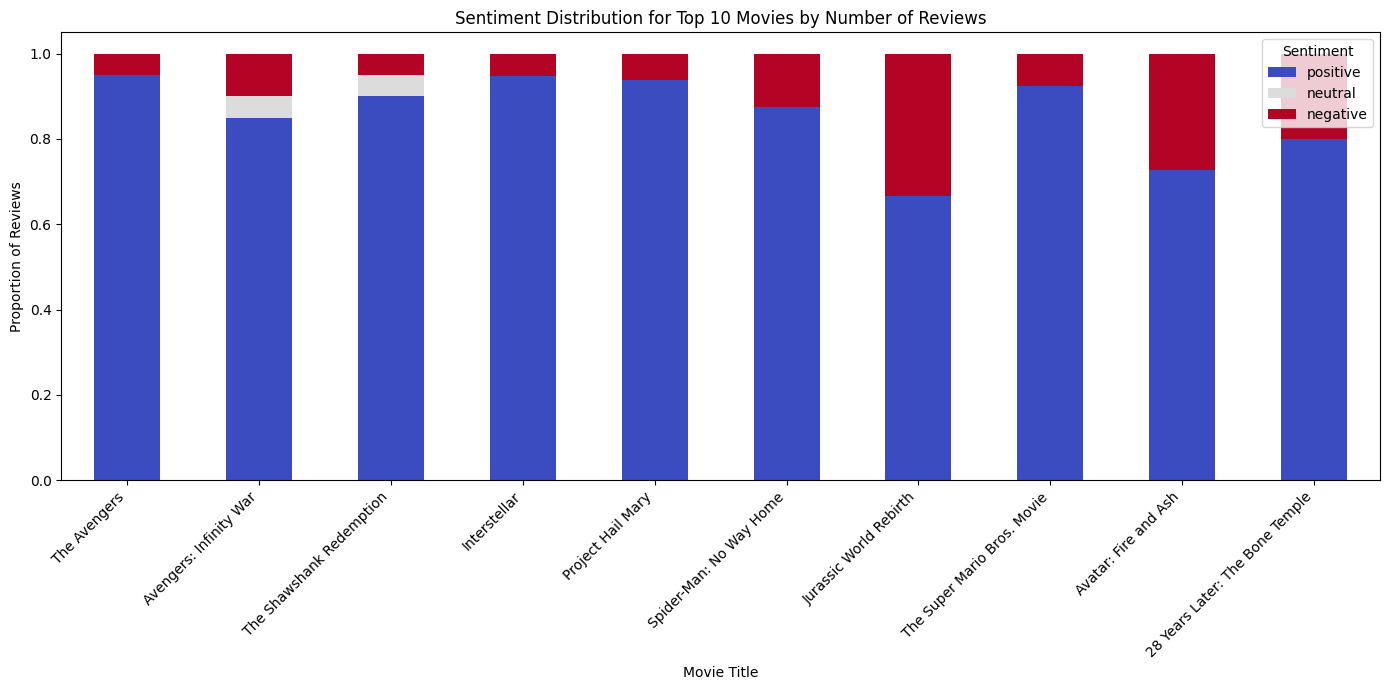

In [14]:
# Calculate sentiment distribution per movie
sentiment_per_movie = df_reviews.groupby('movie_title')['sentiment'].value_counts(normalize=True).unstack(fill_value=0)

# Plotting sentiment distribution for the top 10 movies by number of reviews
top_movies_by_reviews = df_reviews['movie_title'].value_counts().head(10).index
sentiment_per_movie_top = sentiment_per_movie.loc[top_movies_by_reviews]

sentiment_per_movie_top[['positive', 'neutral', 'negative']].plot(kind='bar', stacked=True, figsize=(14, 7), cmap='coolwarm')
plt.title('Sentiment Distribution for Top 10 Movies by Number of Reviews')
plt.xlabel('Movie Title')
plt.ylabel('Proportion of Reviews')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

## Data Visualization: Exploring Movie Characteristics

Let's create several plots to understand the general characteristics of our `popular_movies_df` dataset. This will include distributions of `vote_average` and `popularity`, the frequency of different genres, and movie releases over time.

/tmp/ipykernel_3583/3861427170.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(popular_movies_df['vote_average'], kde=True, bins=10, palette='viridis')
/tmp/ipykernel_3583/3861427170.py:15: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(popular_movies_df['popularity'], kde=True, bins=10, palette='magma')


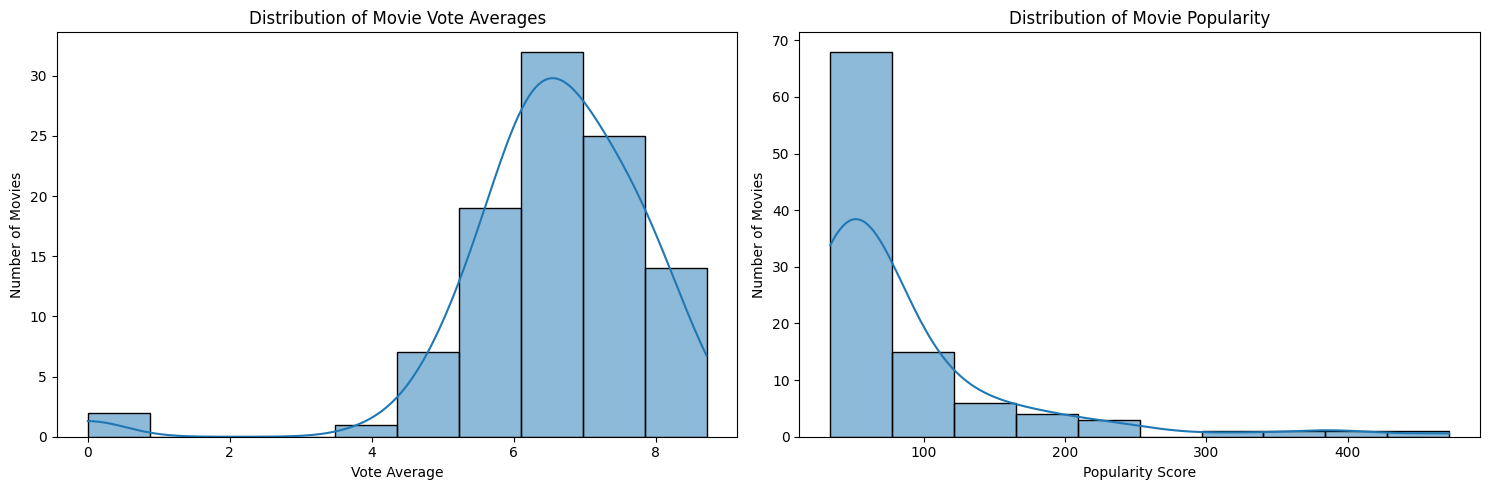

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# Plot 1: Distribution of Vote Average
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(popular_movies_df['vote_average'], kde=True, bins=10, palette='viridis')
plt.title('Distribution of Movie Vote Averages')
plt.xlabel('Vote Average')
plt.ylabel('Number of Movies')

# Plot 2: Distribution of Popularity
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(popular_movies_df['popularity'], kde=True, bins=10, palette='magma')
plt.title('Distribution of Movie Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Movies')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3583/920866937.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=all_genres, order=all_genres.value_counts().index, palette='rocket')


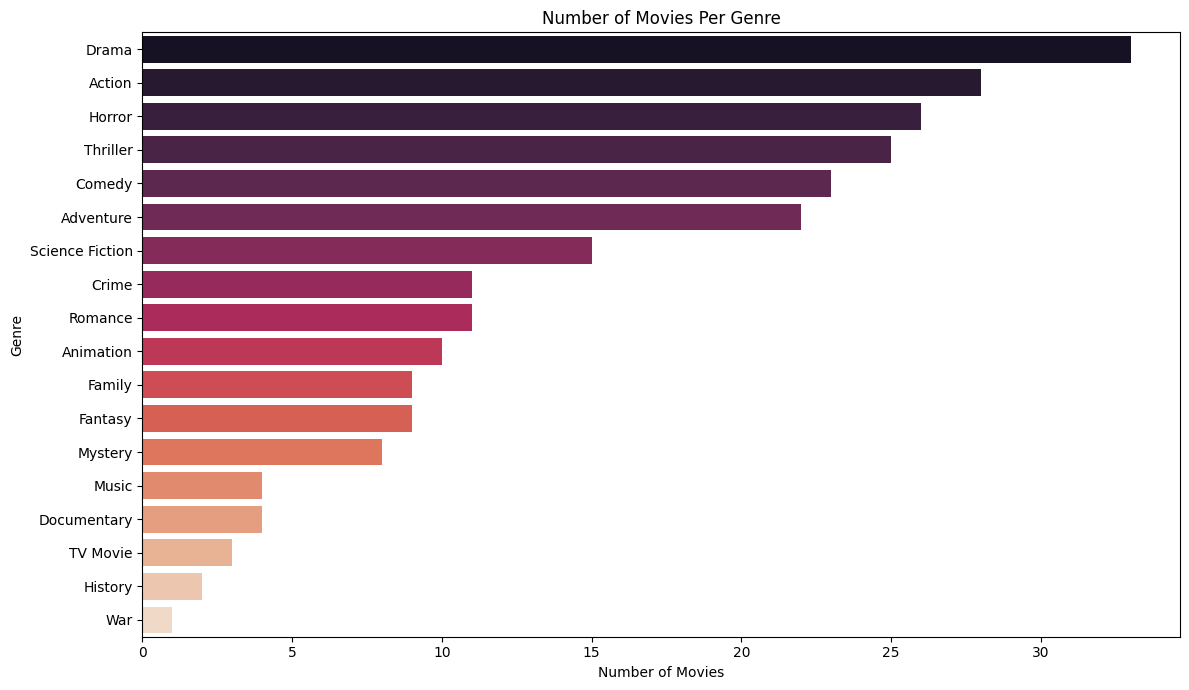

In [10]:
# To analyze genres, we first need to flatten the list of genres into a single series
all_genres = popular_movies_df['genres'].explode()

plt.figure(figsize=(12, 7))
sns.countplot(y=all_genres, order=all_genres.value_counts().index, palette='rocket')
plt.title('Number of Movies Per Genre')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

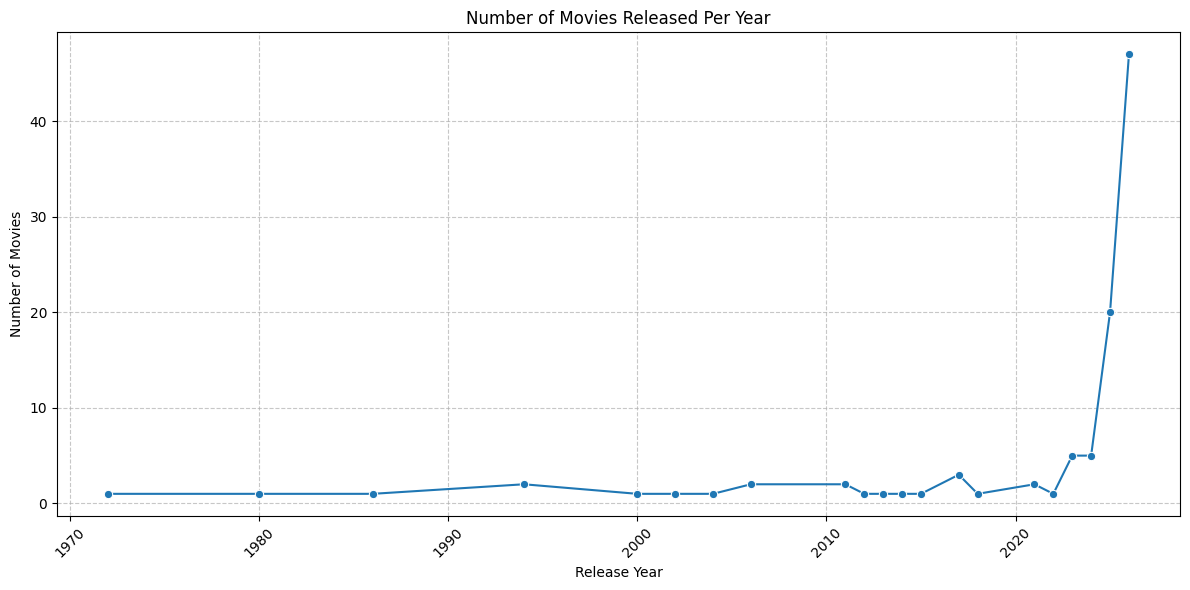

In [11]:
# Convert release_date to datetime and extract year
popular_movies_df['release_year'] = pd.to_datetime(popular_movies_df['release_date'], errors='coerce').dt.year

# Filter out NaN years and count movies per year
movies_per_year = popular_movies_df.dropna(subset=['release_year'])
movies_per_year = movies_per_year['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=movies_per_year.index, y=movies_per_year.values, marker='o')
plt.title('Number of Movies Released Per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()